In [2]:
# ==============================================================================
# PASO 1: PREPARACIÓN Y LIMPIEZA DEL DATASET DERMNET
# ==============================================================================
# Este script escanea el directorio de Dermnet, calcula el phash de cada imagen,
# identifica duplicados visuales y guarda un CSV limpio con las rutas
# a las imágenes únicas.
# ------------------------------------------------------------------------------

import os
import pandas as pd
from PIL import Image
import imagehash
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# --- CONFIGURACIÓN ---
DERMNET_PATH = "/kaggle/input/dermnet/DermNet"
OUTPUT_CSV_PATH = "/kaggle/working/dermnet_no_dupes.csv"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# --- FUNCIONES AUXILIARES (extraídas de tu pipeline) ---

def is_image_file(fname):
    return os.path.splitext(fname)[1].lower() in IMG_EXTS

def scan_and_compute_phash(root_path, source_name="dermnet"):
    records = []
    print(f"Escaneando {root_path} y calculando phash...")
    if not os.path.exists(root_path):
        print(f"ERROR: La ruta no existe: {root_path}")
        return pd.DataFrame()
        
    for dirpath, _, files in os.walk(root_path):
        for f in files:
            if not is_image_file(f):
                continue
            filepath = os.path.join(dirpath, f)
            label = os.path.basename(dirpath) # La carpeta contenedora es la etiqueta
            
            phash_hex = None
            try:
                img = Image.open(filepath).convert("RGB")
                phash_hex = str(imagehash.phash(img))
            except Exception as e:
                print(f"  ERROR leyendo {filepath}: {e}")
            
            records.append({
                "filepath": filepath,
                "label": label,
                "source": source_name,
                "phash_hex": phash_hex
            })
    return pd.DataFrame(records)

def list_exact_duplicate_groups(df):
    d = defaultdict(list)
    for _, r in df.iterrows():
        ph = r.get("phash_hex", None)
        if ph:
            d[ph].append(r["filepath"])
    return {ph: paths for ph, paths in d.items() if len(paths) > 1}

# --- EJECUCIÓN DEL PIPELINE DE LIMPIEZA ---

# 1. Escanear y calcular phash
df_phash = scan_and_compute_phash(DERMNET_PATH)
print(f"\nTotal imágenes detectadas en Dermnet: {len(df_phash)}")

if not df_phash.empty:
    # 2. Detectar y listar duplicados
    duplicate_groups = list_exact_duplicate_groups(df_phash)
    print(f"\nSe encontraron {len(duplicate_groups)} grupos de imágenes duplicadas.")
    
    # 3. Eliminar duplicados del DataFrame (manteniendo la primera ocurrencia)
    to_drop = set()
    for paths in duplicate_groups.values():
        to_drop.update(paths[1:]) # Añadir a la lista de eliminación todos menos el primero
        
    print(f"\nSe eliminarán {len(to_drop)} imágenes duplicadas del manifiesto.")
    df_no_dupes = df_phash[~df_phash['filepath'].isin(to_drop)].reset_index(drop=True)

    # 4. Guardar el CSV limpio
    df_no_dupes.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"\nManifiesto CSV limpio guardado en: {OUTPUT_CSV_PATH}")
    print(f"El dataset limpio contiene {len(df_no_dupes)} imágenes únicas.")
else:
    print("No se procesaron imágenes. Verifique la ruta del dataset.")

Escaneando /kaggle/input/dermnet/DermNet y calculando phash...

Total imágenes detectadas en Dermnet: 570

Se encontraron 16 grupos de imágenes duplicadas.

Se eliminarán 16 imágenes duplicadas del manifiesto.

Manifiesto CSV limpio guardado en: /kaggle/working/dermnet_no_dupes.csv
El dataset limpio contiene 554 imágenes únicas.


In [1]:
import shutil
import os

# Define la ruta del archivo que deseas copiar
ruta_origen = '/kaggle/input/progreso/loocv_progress_dermnet (13).json'

# Define la ruta del directorio de destino
ruta_destino = '/kaggle/working/'

# Crea el directorio de destino si no existe
os.makedirs(ruta_destino, exist_ok=True)

# Define el nuevo nombre del archivo
nuevo_nombre = 'loocv_progress_dermnet.json'

# Copia el archivo al directorio de destino con el nuevo nombre
shutil.copy(ruta_origen, os.path.join(ruta_destino, nuevo_nombre))

print("Archivo copiado y renombrado con éxito.")

Archivo copiado y renombrado con éxito.


2025-08-27 09:00:19.431531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756285219.621884   11622 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756285219.677007   11622 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Cargando el dataset limpio de Dermnet para LOOCV...
Cargando 554 imágenes desde el manifiesto CSV...
Total de imágenes únicas cargadas: 554
Progreso cargado. Reanudando desde el fold 551.

Iniciando/Reanudando LOOCV (554 iteraciones)...
Saltando folds hasta el 551...

Procesando Fold LOOCV 551/554
Balanceando 553 muestras de entrenamiento...


I0000 00:00:1756285235.376838   11622 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756285235.377480   11622 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1756285254.434231   11658 service.cc:148] XLA service 0x7ec6ac093510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756285254.434802   11658 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756285254.434824   11658 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756285256.177605   11658 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756285265.873187   11658 device_compiler.h:188] Compiled clust

  Fold 551: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 552/554
Balanceando 553 muestras de entrenamiento...
  Fold 552: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 553/554
Balanceando 553 muestras de entrenamiento...
  Fold 553: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Eritrodermica'. Accuracy: 0.0

Procesando Fold LOOCV 554/554
Balanceando 553 muestras de entrenamiento...
  Fold 554: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

--- Resultados Finales de LOOCV ---

Precisión Promedio Final de LOOCV: 86.28%

Informe de Clasificación - LOOCV:
                         precision    recall  f1-score   support

Psoriasis Eritrodermica       0.78      0.79      0.78        48
      Psoriasis Guttata       0.85      0.93      0.89       109
      Psoriasis Inversa       0.90      0.94      0.92        88
    Psoriasis Pustulosa     

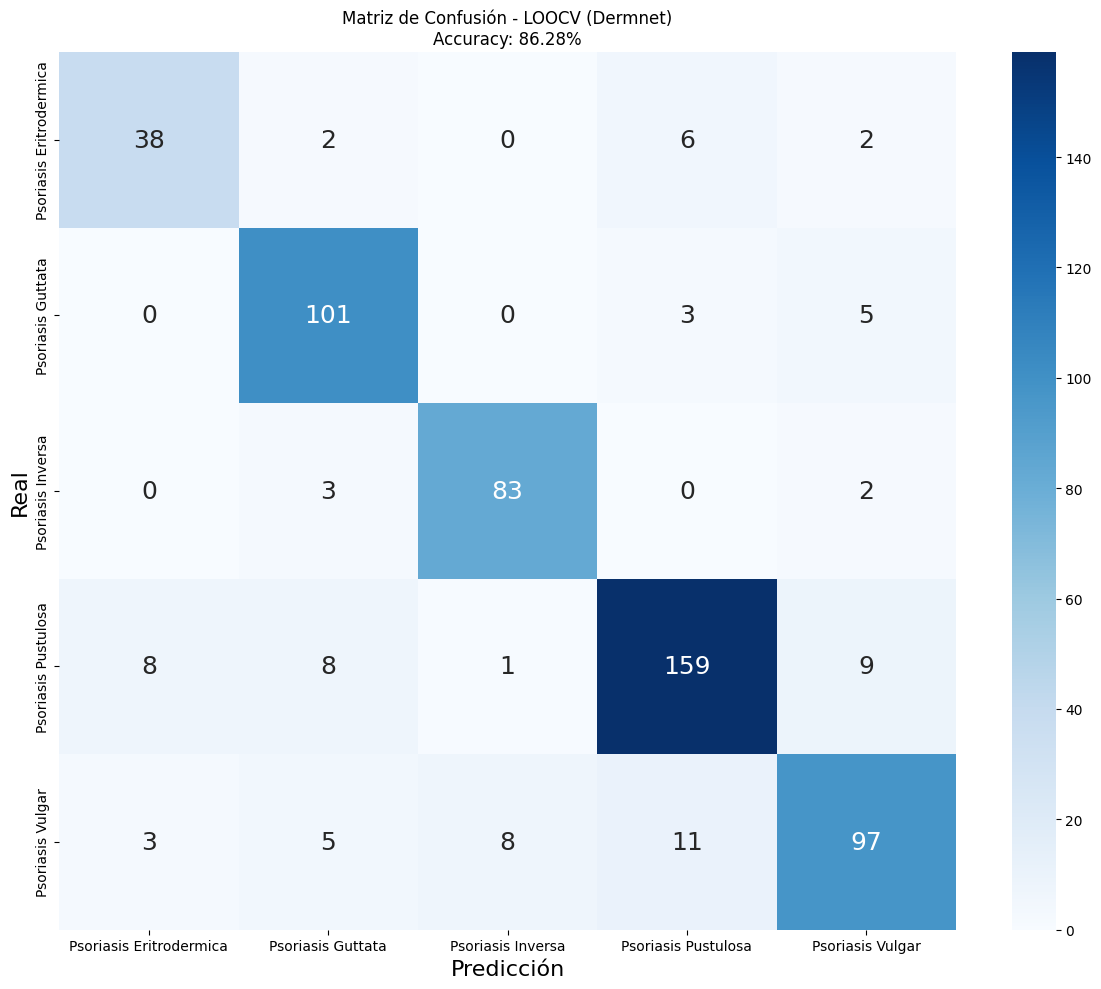

In [1]:
# ==============================================================================
# PASO 2: EJECUCIÓN DE LOOCV SOBRE EL DATASET DERMNET LIMPIO (VERSIÓN CORREGIDA)
# ==============================================================================
# CORRECCIÓN: Se ha restaurado la lógica para guardar y cargar la lista
# 'fold_accuracies' en el archivo de progreso JSON.
# ------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
import gc
import json

# --- Configuración General ---
CLEAN_CSV_PATH = '/kaggle/working/dermnet_no_dupes.csv'
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_LOOCV = 10
RANDOM_SEED = 45
LEARNING_RATE = 0.001
PROGRESS_FILE = '/kaggle/working/loocv_progress_dermnet.json'

# --- Funciones de Utilidad ---

def load_data_from_csv(csv_path, img_size):
    """Carga y preprocesa imágenes listadas en un manifiesto CSV."""
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"ERROR: No se encontró el archivo {csv_path}. Asegúrate de ejecutar el Paso 1 primero.")
        return None, None, None
        
    images, labels = [], []
    class_names = sorted(df['label'].unique())
    class_indices = {name: i for i, name in enumerate(class_names)}
    
    print(f"Cargando {len(df)} imágenes desde el manifiesto CSV...")
    for _, row in df.iterrows():
        try:
            img = tf.keras.preprocessing.image.load_img(row['filepath'], target_size=(img_size, img_size))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(class_indices[row['label']])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    return np.array(images), np.array(labels), class_names

def balance_dataset_with_augmentation(X_data, y_data, class_names_list):
    """Balancea el dataset de entrenamiento usando data augmentation."""
    print(f"Balanceando {len(X_data)} muestras de entrenamiento...")
    datagen = ImageDataGenerator(
        rotation_range=30, width_shift_range=0.3, height_shift_range=0.3,
        shear_range=0.3, zoom_range=0.3, horizontal_flip=True, fill_mode='nearest'
    )
    class_counts = Counter(y_data)
    if not class_counts: return np.array([]), tf.keras.utils.to_categorical(np.array([]), num_classes=len(class_names_list))

    max_count = max(class_counts.values())
    X_balanced, y_balanced = list(X_data), list(y_data)

    for class_idx in range(len(class_names_list)):
        current_indices = np.where(y_data == class_idx)[0]
        current_count = len(current_indices)
        if 0 < current_count < max_count:
            needed = max_count - current_count
            images_to_augment = X_data[current_indices]
            augmented_count = 0
            idx_img_to_augment = 0
            while augmented_count < needed:
                img_original = images_to_augment[idx_img_to_augment % len(images_to_augment)]
                img = np.expand_dims(img_original, 0)
                batch = next(datagen.flow(img, batch_size=1))
                X_balanced.append(batch[0])
                y_balanced.append(class_idx)
                augmented_count += 1
                idx_img_to_augment +=1
    return np.array(X_balanced), tf.keras.utils.to_categorical(np.array(y_balanced), num_classes=len(class_names_list))

def create_efficientnet_model_frozen_base(input_shape, num_classes_model):
    """Crea el modelo EfficientNetB0 con la base congelada y el clasificador personalizado."""
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes_model, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- Pipeline Principal ---

print("Cargando el dataset limpio de Dermnet para LOOCV...")
X_all, y_all, class_names = load_data_from_csv(CLEAN_CSV_PATH, IMG_SIZE)
if X_all is None or X_all.size == 0: 
    raise ValueError("No se cargaron imágenes. Ejecuta el Paso 1 primero.")
num_classes = len(class_names)
total_samples = len(X_all)
print(f"Total de imágenes únicas cargadas: {total_samples}")

# Cargar progreso si existe
start_fold_idx = 0
all_true_labels_loo, all_pred_labels_loo, fold_accuracies_loo = [], [], [] # <-- Inicializar la lista aquí
if os.path.exists(PROGRESS_FILE):
    try:
        with open(PROGRESS_FILE, 'r') as f:
            progress_data = json.load(f)
        start_fold_idx = progress_data.get('next_fold_idx', 0)
        all_true_labels_loo = progress_data.get('true_labels', [])
        all_pred_labels_loo = progress_data.get('pred_labels', [])
        fold_accuracies_loo = progress_data.get('fold_accuracies', []) # <-- CARGAR LA LISTA
        print(f"Progreso cargado. Reanudando desde el fold {start_fold_idx + 1}.")
    except Exception as e:
        print(f"Error cargando progreso: {e}. Empezando desde cero.")
        start_fold_idx = 0
else:
    print("No se encontró archivo de progreso. Empezando desde cero.")

# Bucle LOOCV
loo = LeaveOneOut()
if start_fold_idx < total_samples:
    print(f"\nIniciando/Reanudando LOOCV ({total_samples} iteraciones)...")
    for fold_idx, (train_indices, val_indices) in enumerate(loo.split(X_all)):
        if fold_idx < start_fold_idx:
            if fold_idx == 0: print(f"Saltando folds hasta el {start_fold_idx + 1}...")
            continue

        print(f"\nProcesando Fold LOOCV {fold_idx + 1}/{total_samples}")
        X_train_loo, X_val_loo = X_all[train_indices], X_all[val_indices]
        y_train_loo, y_val_loo = y_all[train_indices], y_all[val_indices]

        X_train_loo_balanced, y_train_loo_balanced_categorical = balance_dataset_with_augmentation(
            X_train_loo, y_train_loo, class_names
        )

        if X_train_loo_balanced.size == 0:
            print(f"Fold {fold_idx + 1} saltado: no hay datos de entrenamiento.")
            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(-1)
            fold_accuracies_loo.append(0.0) # <-- Añadir 0.0 si falla
        else:
            model_loo = create_efficientnet_model_frozen_base((IMG_SIZE, IMG_SIZE, 3), num_classes)
            model_loo.fit(
                X_train_loo_balanced, y_train_loo_balanced_categorical,
                epochs=EPOCHS_LOOCV, batch_size=BATCH_SIZE, verbose=0
            )
            y_pred_prob_fold = model_loo.predict(X_val_loo, verbose=0)
            y_pred_class_fold = np.argmax(y_pred_prob_fold, axis=1)[0]

            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(int(y_pred_class_fold))
            
            # Lógica para calcular el acierto/error del fold
            accuracy_this_fold = 1.0 if y_pred_class_fold == y_val_loo[0] else 0.0
            fold_accuracies_loo.append(accuracy_this_fold) # <-- AÑADIR EL RESULTADO A LA LISTA
            
            print(f"  Fold {fold_idx + 1}: Verdadera='{class_names[y_val_loo[0]]}', Predicha='{class_names[y_pred_class_fold]}'. Accuracy: {accuracy_this_fold}")
            
            del model_loo
            tf.keras.backend.clear_session()
            gc.collect()

        # Guardar progreso
        progress_data_to_save = {
            'next_fold_idx': fold_idx + 1,
            'true_labels': all_true_labels_loo,
            'pred_labels': all_pred_labels_loo,
            'fold_accuracies': fold_accuracies_loo # <-- INCLUIR LA LISTA AL GUARDAR
        }
        try:
            with open(PROGRESS_FILE, 'w') as f:
                json.dump(progress_data_to_save, f)
        except Exception as e:
            print(f"    Error guardando progreso: {e}")

# --- Análisis de Resultados Finales de LOOCV ---
print("\n--- Resultados Finales de LOOCV ---")
if all_true_labels_loo:
    valid_indices = [i for i, pred in enumerate(all_pred_labels_loo) if pred != -1]
    y_true_filtered = np.array(all_true_labels_loo)[valid_indices]
    y_pred_filtered = np.array(all_pred_labels_loo)[valid_indices]
    
    mean_loocv_accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    print(f"\nPrecisión Promedio Final de LOOCV: {mean_loocv_accuracy:.2%}")

    print("\nInforme de Clasificación - LOOCV:")
    print(classification_report(y_true_filtered, y_pred_filtered, labels=np.arange(num_classes), target_names=class_names, zero_division=0))
    
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=np.arange(num_classes))
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
    plt.title(f'Matriz de Confusión - LOOCV (Dermnet)\nAccuracy: {mean_loocv_accuracy:.2%}')
    plt.xlabel('Predicción',fontsize=16)
    plt.ylabel('Real',fontsize=16)
    plt.tight_layout()
    plt.savefig("/kaggle/working/matriz_confusion_loocv_dermnet.png", dpi=300)
    plt.show()
else:
    print("No hay resultados de LOOCV para analizar.")

## Roboflow


In [1]:
import shutil
import os

# Define la ruta del archivo que deseas copiar
ruta_origen = '/kaggle/input/progreso/loocv_progress_roboflow_dermnet_hospital (20).json'

# Define la ruta del directorio de destino
ruta_destino = '/kaggle/working/'

# Crea el directorio de destino si no existe
os.makedirs(ruta_destino, exist_ok=True)

# Define el nuevo nombre del archivo
nuevo_nombre = 'loocv_progress_roboflow_dermnet_hospital.json'

# Copia el archivo al directorio de destino con el nuevo nombre
shutil.copy(ruta_origen, os.path.join(ruta_destino, nuevo_nombre))

print("Archivo copiado y renombrado con éxito.")

Archivo copiado y renombrado con éxito.


2025-08-30 21:34:06.032401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756589646.237125      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756589646.298628      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- PASO 1: Preparando Manifiesto para /kaggle/input/roboflow-universe-dataset/Roboflow Universe ---
  449 imágenes encontradas, 4 duplicados eliminados.
  Manifiesto limpio con 445 imágenes únicas guardado en: /kaggle/working/roboflow_no_dupes.csv

--- PASO 2: Cargando Datos para LOOCV ---
Cargando 445 imágenes desde el manifiesto CSV...
Total de imágenes únicas para LOOCV: 445
Progreso cargado. Reanudando desde el fold 418.

--- PASO 3: Iniciando/Reanudando LOOCV (445 iteraciones) ---
Saltando folds hasta el 418...

Procesando Fold LOOCV 418/445
Balanceando 444 muestras de entrenamiento...


I0000 00:00:1756589666.013061      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756589666.013774      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1756589685.593294     101 service.cc:148] XLA service 0x785f980550e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756589685.594205     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756589685.594224     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756589687.469152     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756589696.819131     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Fold 418: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 419/445
Balanceando 444 muestras de entrenamiento...
  Fold 419: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 420/445
Balanceando 444 muestras de entrenamiento...
  Fold 420: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 421/445
Balanceando 444 muestras de entrenamiento...
  Fold 421: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 422/445
Balanceando 444 muestras de entrenamiento...
  Fold 422: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 423/445
Balanceando 444 muestras de entrenamiento...
  Fold 423: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 424/445
Balanceando 444 muestras de entrenamiento..

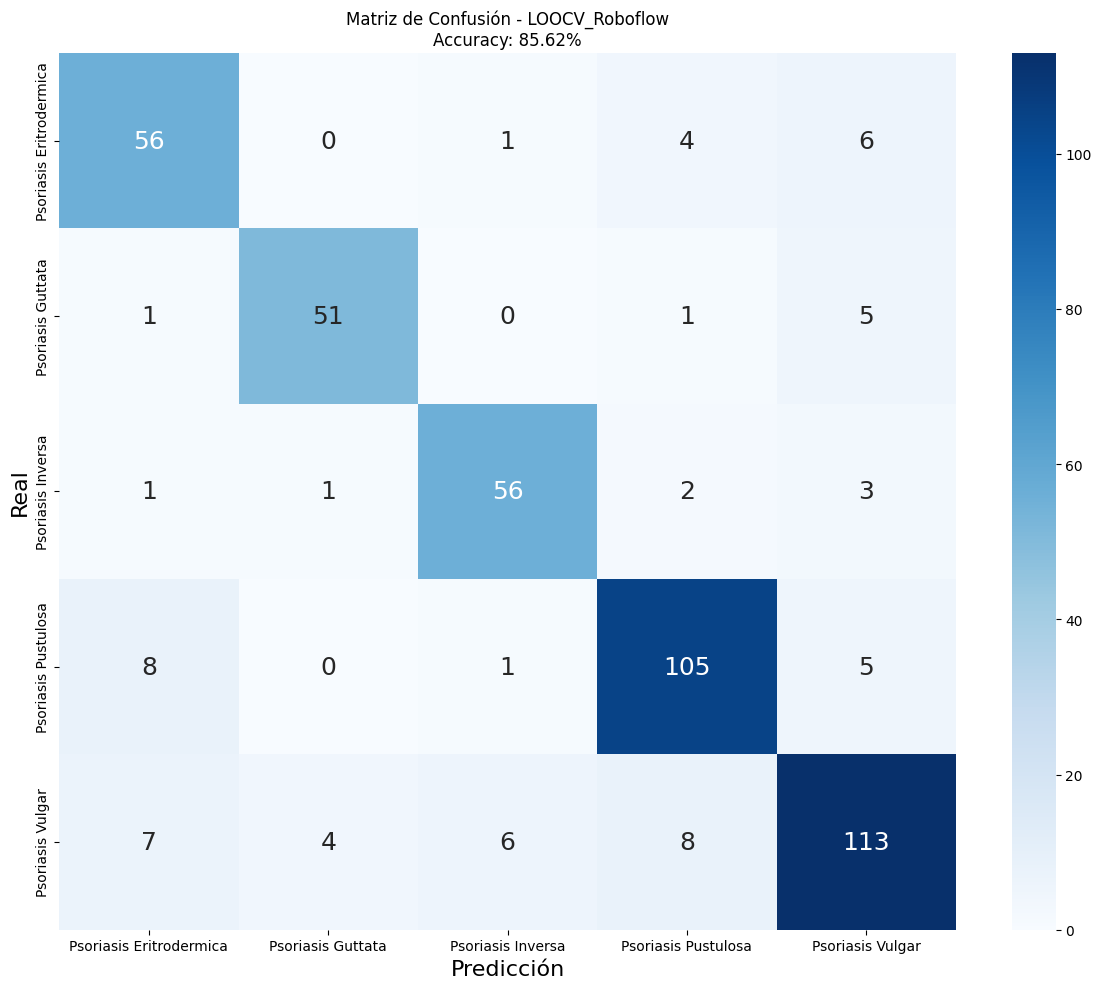

In [2]:
# ==============================================================================
# SCRIPT UNIFICADO Y FLEXIBLE PARA EJECUTAR LOOCV EN CUALQUIER DATASET
# ==============================================================================
# Este script realiza el proceso completo:
# 1. Escanea un directorio de entrada, eliminando duplicados visuales (phash).
# 2. Guarda un manifiesto CSV limpio de las imágenes únicas.
# 3. Ejecuta la Validación Cruzada Leave-One-Out (LOOCV) sobre ese dataset limpio.
# 4. Guarda los resultados y el progreso para poder reanudar la ejecución.
# ------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter, defaultdict
import gc
import json
from PIL import Image
import imagehash
import warnings
warnings.filterwarnings("ignore")


### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###
# ------------------------------------------------------------------------------
#               MODIFICA ESTAS LÍNEAS PARA CADA EXPERIMENTO
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "LOOCV_Roboflow"
DATASET_PATH    = "/kaggle/input/roboflow-universe-dataset/Roboflow Universe" 
OUTPUT_PREFIX   = "roboflow" # Prefijo para los archivos de salida 
# ------------------------------------------------------------------------------

# --- Configuración General (normalmente no necesita cambios) ---
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_LOOCV = 10 # Aumenta si ves que los modelos no convergen
RANDOM_SEED = 45
LEARNING_RATE = 0.001
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# --- Rutas de Archivos de Salida (se generan automáticamente) ---
OUTPUT_DIR = "/kaggle/working/"
CLEAN_CSV_PATH = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_no_dupes.csv")
PROGRESS_FILE = os.path.join(OUTPUT_DIR, f"loocv_progress_{OUTPUT_PREFIX}.json")
CM_FILE_PATH = os.path.join(OUTPUT_DIR, f"matriz_confusion_loocv_{OUTPUT_PREFIX}.png")


### --- 2. FUNCIONES AUXILIARES --- ###

def normalize_label_text(lbl):
    """Unifica los nombres de las etiquetas para evitar inconsistencias."""
    if pd.isna(lbl): return lbl
    s = str(lbl).strip().lower().replace('-', ' ').replace('_', ' ')
    if 'pustular' in s or 'pustul' in s: return "Psoriasis Pustulosa"
    if 'vulgar' in s or 'plaque' in s or 'plaqu' in s: return "Psoriasis Vulgar"
    if 'guttate' in s or 'gutt' in s: return "Psoriasis Guttata"
    if 'inverse' in s or 'inversa' in s: return "Psoriasis Inversa"
    if 'erythrodermic' in s or 'eritro' in s or 'eryth' in s: return "Psoriasis Eritrodermica"
    return str(lbl).strip().title()
    
def prepare_clean_manifest(root_path, output_csv_path):
    """Escanea, elimina duplicados y guarda un manifiesto CSV limpio."""
    print(f"--- PASO 1: Preparando Manifiesto para {root_path} ---")
    records = []
    for dirpath, _, files in os.walk(root_path):
        for f in files:
            if os.path.splitext(f)[1].lower() not in IMG_EXTS: continue
            filepath = os.path.join(dirpath, f)
            label = normalize_label_text(os.path.basename(dirpath))
            try:
                img = Image.open(filepath).convert("RGB")
                phash_hex = str(imagehash.phash(img))
                records.append({"filepath": filepath, "label": label, "phash_hex": phash_hex})
            except Exception as e:
                print(f"  WARN: No se pudo leer {filepath}: {e}")
    
    df = pd.DataFrame(records)
    if df.empty:
        print("No se encontraron imágenes. Abortando.")
        return None
        
    d = defaultdict(list)
    for _, r in df.iterrows():
        if r.get("phash_hex"): d[r.get("phash_hex")].append(r["filepath"])
    
    to_drop = set(p for paths in d.values() for p in paths[1:])
    df_clean = df[~df['filepath'].isin(to_drop)].reset_index(drop=True)
    
    df_clean.to_csv(output_csv_path, index=False)
    print(f"  {len(df)} imágenes encontradas, {len(to_drop)} duplicados eliminados.")
    print(f"  Manifiesto limpio con {len(df_clean)} imágenes únicas guardado en: {output_csv_path}")
    return df_clean

def load_data_from_csv(csv_path, img_size):
    df = pd.read_csv(csv_path)
    images, labels = [], []
    class_names = sorted(df['label'].unique())
    class_indices = {name: i for i, name in enumerate(class_names)}
    print(f"Cargando {len(df)} imágenes desde el manifiesto CSV...")
    for _, row in df.iterrows():
        try:
            img = tf.keras.preprocessing.image.load_img(row['filepath'], target_size=(img_size, img_size))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(class_indices[row['label']])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
    return np.array(images), np.array(labels), class_names

def balance_dataset_with_augmentation(X_data, y_data, num_classes):
    print(f"Balanceando {len(X_data)} muestras de entrenamiento...")
    datagen = ImageDataGenerator(rotation_range=30, width_shift_range=0.3, height_shift_range=0.3, shear_range=0.3, zoom_range=0.3, horizontal_flip=True, fill_mode='nearest')
    class_counts = Counter(y_data)
    if not class_counts: return np.array([]), tf.keras.utils.to_categorical(np.array([]), num_classes=num_classes)
    max_count = max(class_counts.values())
    X_balanced, y_balanced = list(X_data), list(y_data)
    for class_idx in range(num_classes):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < max_count:
            needed = max_count - current_count
            images_to_augment = X_data[y_data == class_idx]
            for i in range(needed):
                img_original = images_to_augment[i % len(images_to_augment)]
                img = np.expand_dims(img_original, 0)
                batch = next(datagen.flow(img, batch_size=1, seed=RANDOM_SEED + i))
                X_balanced.append(batch[0])
                y_balanced.append(class_idx)
    return np.array(X_balanced), tf.keras.utils.to_categorical(np.array(y_balanced), num_classes=num_classes)

def create_efficientnet_model_frozen_base(input_shape, num_classes_model):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
   
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


### --- 3. PIPELINE PRINCIPAL --- ###

# 1. Preparar el manifiesto limpio
df_clean = prepare_clean_manifest(DATASET_PATH, CLEAN_CSV_PATH)
if df_clean is None:
    raise SystemExit("El pipeline se detuvo porque no se encontraron imágenes.")
    
# 2. Cargar datos desde el manifiesto limpio
print(f"\n--- PASO 2: Cargando Datos para LOOCV ---")
X_all, y_all, class_names = load_data_from_csv(CLEAN_CSV_PATH, IMG_SIZE)
if X_all is None or X_all.size == 0: 
    raise ValueError("No se cargaron imágenes desde el CSV.")
NUM_CLASSES = len(class_names)
total_samples = len(X_all)
print(f"Total de imágenes únicas para LOOCV: {total_samples}")

# 3. Cargar progreso si existe
start_fold_idx = 0
all_true_labels_loo, all_pred_labels_loo, fold_accuracies_loo = [], [], []
if os.path.exists(PROGRESS_FILE):
    try:
        with open(PROGRESS_FILE, 'r') as f:
            progress_data = json.load(f)
        start_fold_idx = progress_data.get('next_fold_idx', 0)
        all_true_labels_loo = progress_data.get('true_labels', [])
        all_pred_labels_loo = progress_data.get('pred_labels', [])
        fold_accuracies_loo = progress_data.get('fold_accuracies', [])
        print(f"Progreso cargado. Reanudando desde el fold {start_fold_idx + 1}.")
    except Exception as e:
        print(f"Error cargando progreso: {e}. Empezando desde cero.")
        start_fold_idx = 0
else:
    print("No se encontró archivo de progreso. Empezando desde cero.")

# 4. Bucle LOOCV
loo = LeaveOneOut()
if start_fold_idx < total_samples:
    print(f"\n--- PASO 3: Iniciando/Reanudando LOOCV ({total_samples} iteraciones) ---")
    for fold_idx, (train_indices, val_indices) in enumerate(loo.split(X_all)):
        if fold_idx < start_fold_idx:
            if fold_idx == 0: print(f"Saltando folds hasta el {start_fold_idx + 1}...")
            continue

        print(f"\nProcesando Fold LOOCV {fold_idx + 1}/{total_samples}")
        X_train_loo, X_val_loo = X_all[train_indices], X_all[val_indices]
        y_train_loo, y_val_loo = y_all[train_indices], y_all[val_indices]

        X_train_loo_balanced, y_train_loo_balanced_categorical = balance_dataset_with_augmentation(X_train_loo, y_train_loo, NUM_CLASSES)

        if X_train_loo_balanced.size == 0:
            print(f"Fold {fold_idx + 1} saltado: no hay datos de entrenamiento.")
            all_true_labels_loo.append(int(y_val_loo[0])); all_pred_labels_loo.append(-1); fold_accuracies_loo.append(0.0)
        else:
            model_loo = create_efficientnet_model_frozen_base((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
            model_loo.fit(X_train_loo_balanced, y_train_loo_balanced_categorical, epochs=EPOCHS_LOOCV, batch_size=BATCH_SIZE, verbose=0)
            y_pred_prob_fold = model_loo.predict(X_val_loo, verbose=0)
            y_pred_class_fold = np.argmax(y_pred_prob_fold, axis=1)[0]

            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(int(y_pred_class_fold))
            accuracy_this_fold = 1.0 if y_pred_class_fold == y_val_loo[0] else 0.0
            fold_accuracies_loo.append(accuracy_this_fold)
            
            print(f"  Fold {fold_idx + 1}: Verdadera='{class_names[y_val_loo[0]]}', Predicha='{class_names[y_pred_class_fold]}'. Accuracy: {accuracy_this_fold}")
            del model_loo
            tf.keras.backend.clear_session(); gc.collect()

        # Guardar progreso
        progress_data_to_save = {
            'next_fold_idx': fold_idx + 1,
            'true_labels': all_true_labels_loo,
            'pred_labels': all_pred_labels_loo,
            'fold_accuracies': fold_accuracies_loo
        }
        with open(PROGRESS_FILE, 'w') as f:
            json.dump(progress_data_to_save, f)

# 5. Análisis de Resultados Finales de LOOCV
print("\n--- PASO 4: Resultados Finales de LOOCV ---")
if all_true_labels_loo:
    valid_indices = [i for i, pred in enumerate(all_pred_labels_loo) if pred != -1]
    y_true_filtered = np.array(all_true_labels_loo)[valid_indices]
    y_pred_filtered = np.array(all_pred_labels_loo)[valid_indices]
    
    mean_loocv_accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    print(f"\nPrecisión Promedio Final de LOOCV: {mean_loocv_accuracy:.2%}")
    print("\nInforme de Clasificación - LOOCV:")
    print(classification_report(y_true_filtered, y_pred_filtered, labels=np.arange(NUM_CLASSES), target_names=class_names, zero_division=0))
    
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=np.arange(NUM_CLASSES))
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
    plt.title(f'Matriz de Confusión - {EXPERIMENT_NAME}\nAccuracy: {mean_loocv_accuracy:.2%}')
    plt.xlabel('Predicción',fontsize=16); plt.ylabel('Real',fontsize=16)
    plt.tight_layout()
    plt.savefig(CM_FILE_PATH, dpi=300); plt.show()
else:
    print("No hay resultados de LOOCV para analizar.")

## Todo el dataset combinado

2025-09-01 11:53:29.205225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756727609.396428   31545 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756727609.449074   31545 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- PASO 1: Preparando Manifiesto para los datasets: ['roboflow', 'dermnet', 'hospital'] ---
  1056 imágenes encontradas, 79 duplicados eliminados.
  Manifiesto limpio con 977 imágenes únicas guardado en: /kaggle/working/roboflow_dermnet_hospital_no_dupes.csv

--- PASO 2: Cargando Datos para LOOCV ---
Cargando 977 imágenes desde el manifiesto CSV...
Total de imágenes únicas para LOOCV: 977
Progreso cargado. Reanudando desde el fold 931.

--- PASO 3: Iniciando/Reanudando LOOCV (977 iteraciones) ---
Saltando folds hasta el 931...

Procesando Fold LOOCV 931/977
Balanceando 976 muestras de entrenamiento...


I0000 00:00:1756727636.074922   31545 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756727636.075645   31545 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1756727658.359314   31583 service.cc:148] XLA service 0x78d238051fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756727658.359871   31583 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756727658.359898   31583 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756727660.293757   31583 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756727670.169111   31583 device_compiler.h:188] Compiled clust

  Fold 931: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 932/977
Balanceando 976 muestras de entrenamiento...
  Fold 932: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 933/977
Balanceando 976 muestras de entrenamiento...
  Fold 933: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 934/977
Balanceando 976 muestras de entrenamiento...
  Fold 934: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Vulgar'. Accuracy: 0.0

Procesando Fold LOOCV 935/977
Balanceando 976 muestras de entrenamiento...
  Fold 935: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 936/977
Balanceando 976 muestras de entrenamiento...
  Fold 936: Verdadera='Psoriasis Pustulosa', Predicha='Psoriasis Pustulosa'. Accuracy: 1.0

Procesando Fold LOOCV 937/977
Balanceando 976 muestras de entrenamiento...
 

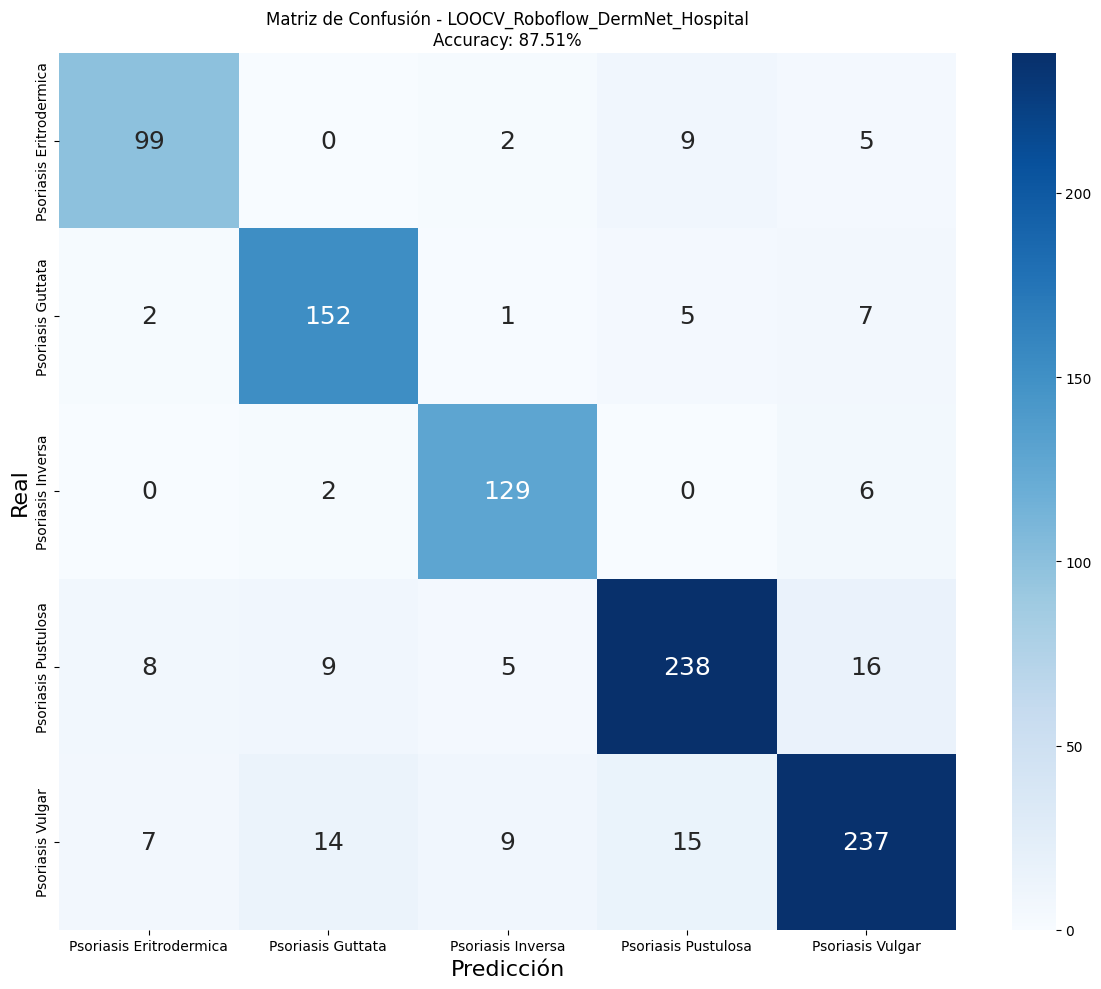

In [1]:
# ==============================================================================
# SCRIPT UNIFICADO Y FLEXIBLE PARA EJECUTAR LOOCV EN CUALQUIER DATASET
# ==============================================================================
# Este script realiza el proceso completo:
# 1. Escanea directorios de entrada, eliminando duplicados visuales (phash).
# 2. Guarda un manifiesto CSV limpio de las imágenes únicas.
# 3. Ejecuta la Validación Cruzada Leave-One-Out (LOOCV) sobre ese dataset limpio.
# 4. Guarda los resultados y el progreso para poder reanudar la ejecución.
# ------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter, defaultdict
import gc
import json
from PIL import Image
import imagehash
import warnings
warnings.filterwarnings("ignore")


### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###
# ------------------------------------------------------------------------------
#         MODIFICA ESTAS LÍNEAS PARA CADA EXPERIMENTO
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "LOOCV_Roboflow_DermNet_Hospital"

# Rutas a los datasets, modifícalas con las ubicaciones correctas.
# Las claves del diccionario son el nombre de la fuente.
DATASET_ROOTS = {
    "roboflow": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe",
    "dermnet": "/kaggle/input/dermnet/DermNet",
    "hospital": "/kaggle/input/imageneshospital/Hospital/Hospital"
}

OUTPUT_PREFIX = "roboflow_dermnet_hospital" # Prefijo para los archivos de salida
# ------------------------------------------------------------------------------

# --- Configuración General (normalmente no necesita cambios) ---
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_LOOCV = 8 
RANDOM_SEED = 45
LEARNING_RATE = 0.001
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# --- Rutas de Archivos de Salida (se generan automáticamente) ---
OUTPUT_DIR = "/kaggle/working/"
CLEAN_CSV_PATH = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_no_dupes.csv")
PROGRESS_FILE = os.path.join(OUTPUT_DIR, f"loocv_progress_{OUTPUT_PREFIX}.json")
CM_FILE_PATH = os.path.join(OUTPUT_DIR, f"matriz_confusion_loocv_{OUTPUT_PREFIX}.png")
REPORT_FILE_PATH = os.path.join(OUTPUT_DIR, f"reporte_loocv_{OUTPUT_PREFIX}.txt")
MAIN_CLASSES = [
    "Psoriasis Vulgar", "Psoriasis Guttata", "Psoriasis Inversa",
    "Psoriasis Pustulosa", "Psoriasis Eritrodermica"
]


### --- 2. FUNCIONES AUXILIARES --- ###

def normalize_label_text(lbl):
    """Unifica los nombres de las etiquetas para evitar inconsistencias."""
    if pd.isna(lbl): return lbl
    s = str(lbl).strip().lower().replace('-', ' ').replace('_', ' ')
    if 'pustular' in s or 'pustul' in s: return "Psoriasis Pustulosa"
    if 'vulgar' in s or 'plaque' in s or 'plaqu' in s: return "Psoriasis Vulgar"
    if 'guttate' in s or 'gutt' in s: return "Psoriasis Guttata"
    if 'inverse' in s or 'inversa' in s: return "Psoriasis Inversa"
    if 'erythrodermic' in s or 'eritro' in s or 'eryth' in s: return "Psoriasis Eritrodermica"
    return str(lbl).strip().title()

def prepare_clean_manifest_from_multiple_roots(roots_dict, output_csv_path):
    """Escanea múltiples directorios, elimina duplicados y guarda un manifiesto CSV limpio."""
    print(f"--- PASO 1: Preparando Manifiesto para los datasets: {list(roots_dict.keys())} ---")
    all_records = []
    
    for source_name, root_path in roots_dict.items():
        if not os.path.exists(root_path):
            print(f"  WARN: La ruta '{root_path}' no existe. Saltando este dataset.")
            continue
        
        records = []
        for dirpath, _, files in os.walk(root_path):
            for f in files:
                if os.path.splitext(f)[1].lower() not in IMG_EXTS: continue
                filepath = os.path.join(dirpath, f)
                label = normalize_label_text(os.path.basename(dirpath))
                
                try:
                    img = Image.open(filepath).convert("RGB")
                    phash_hex = str(imagehash.phash(img))
                    records.append({"filepath": filepath, "label": label, "phash_hex": phash_hex, "source": source_name})
                except Exception as e:
                    print(f"  WARN: No se pudo leer {filepath}: {e}")
        all_records.extend(records)
    
    df = pd.DataFrame(all_records)
    if df.empty:
        print("No se encontraron imágenes. Abortando.")
        return None
        
    d = defaultdict(list)
    for _, r in df.iterrows():
        if r.get("phash_hex"): d[r.get("phash_hex")].append(r["filepath"])
    
    to_drop = set(p for paths in d.values() for p in paths[1:])
    df_clean = df[~df['filepath'].isin(to_drop)].reset_index(drop=True)
    
    df_clean.to_csv(output_csv_path, index=False)
    print(f"  {len(df)} imágenes encontradas, {len(to_drop)} duplicados eliminados.")
    print(f"  Manifiesto limpio con {len(df_clean)} imágenes únicas guardado en: {output_csv_path}")
    return df_clean

def load_data_from_csv(csv_path, img_size):
    df = pd.read_csv(csv_path)
    df_filtered = df[df['label'].isin(MAIN_CLASSES)].copy().reset_index(drop=True)
    images, labels = [], []
    class_names = sorted(df_filtered['label'].unique())
    class_indices = {name: i for i, name in enumerate(class_names)}
    print(f"Cargando {len(df_filtered)} imágenes desde el manifiesto CSV...")
    for _, row in df_filtered.iterrows():
        try:
            img = tf.keras.preprocessing.image.load_img(row['filepath'], target_size=(img_size, img_size))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(class_indices[row['label']])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
    return np.array(images), np.array(labels), class_names

def balance_dataset_with_augmentation(X_data, y_data, num_classes):
    print(f"Balanceando {len(X_data)} muestras de entrenamiento...")
    datagen = ImageDataGenerator(rotation_range=30, width_shift_range=0.3, height_shift_range=0.3, shear_range=0.3, zoom_range=0.3, horizontal_flip=True, fill_mode='nearest')
    class_counts = Counter(y_data)
    if not class_counts: return np.array([]), tf.keras.utils.to_categorical(np.array([]), num_classes=num_classes)
    max_count = max(class_counts.values())
    X_balanced, y_balanced = list(X_data), list(y_data)
    for class_idx in range(num_classes):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < max_count:
            needed = max_count - current_count
            images_to_augment = X_data[y_data == class_idx]
            for i in range(needed):
                img_original = images_to_augment[i % len(images_to_augment)]
                img = np.expand_dims(img_original, 0)
                batch = next(datagen.flow(img, batch_size=1, seed=RANDOM_SEED + i))
                X_balanced.append(batch[0])
                y_balanced.append(class_idx)
    return np.array(X_balanced), tf.keras.utils.to_categorical(np.array(y_balanced), num_classes=num_classes)

def create_efficientnet_model_frozen_base(input_shape, num_classes_model):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes_model, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


### --- 3. PIPELINE PRINCIPAL --- ###

# 1. Preparar el manifiesto limpio
df_clean = prepare_clean_manifest_from_multiple_roots(DATASET_ROOTS, CLEAN_CSV_PATH)
if df_clean is None:
    raise SystemExit("El pipeline se detuvo porque no se encontraron imágenes.")
    
# 2. Cargar datos desde el manifiesto limpio
print(f"\n--- PASO 2: Cargando Datos para LOOCV ---")
X_all, y_all, class_names = load_data_from_csv(CLEAN_CSV_PATH, IMG_SIZE)
if X_all is None or X_all.size == 0: 
    raise ValueError("No se cargaron imágenes desde el CSV.")
NUM_CLASSES = len(class_names)
total_samples = len(X_all)
print(f"Total de imágenes únicas para LOOCV: {total_samples}")

# 3. Cargar progreso si existe
start_fold_idx = 0
all_true_labels_loo, all_pred_labels_loo, fold_accuracies_loo = [], [], []
if os.path.exists(PROGRESS_FILE):
    try:
        with open(PROGRESS_FILE, 'r') as f:
            progress_data = json.load(f)
        start_fold_idx = progress_data.get('next_fold_idx', 0)
        all_true_labels_loo = progress_data.get('true_labels', [])
        all_pred_labels_loo = progress_data.get('pred_labels', [])
        fold_accuracies_loo = progress_data.get('fold_accuracies', [])
        print(f"Progreso cargado. Reanudando desde el fold {start_fold_idx + 1}.")
    except Exception as e:
        print(f"Error cargando progreso: {e}. Empezando desde cero.")
        start_fold_idx = 0
else:
    print("No se encontró archivo de progreso. Empezando desde cero.")

# 4. Bucle LOOCV
loo = LeaveOneOut()
if start_fold_idx < total_samples:
    print(f"\n--- PASO 3: Iniciando/Reanudando LOOCV ({total_samples} iteraciones) ---")
    for fold_idx, (train_indices, val_indices) in enumerate(loo.split(X_all)):
        if fold_idx < start_fold_idx:
            if fold_idx == 0: print(f"Saltando folds hasta el {start_fold_idx + 1}...")
            continue

        print(f"\nProcesando Fold LOOCV {fold_idx + 1}/{total_samples}")
        X_train_loo, X_val_loo = X_all[train_indices], X_all[val_indices]
        y_train_loo, y_val_loo = y_all[train_indices], y_all[val_indices]

        X_train_loo_balanced, y_train_loo_balanced_categorical = balance_dataset_with_augmentation(X_train_loo, y_train_loo, NUM_CLASSES)

        if X_train_loo_balanced.size == 0:
            print(f"Fold {fold_idx + 1} saltado: no hay datos de entrenamiento.")
            all_true_labels_loo.append(int(y_val_loo[0])); all_pred_labels_loo.append(-1); fold_accuracies_loo.append(0.0)
        else:
            model_loo = create_efficientnet_model_frozen_base((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
            model_loo.fit(X_train_loo_balanced, y_train_loo_balanced_categorical, epochs=EPOCHS_LOOCV, batch_size=BATCH_SIZE, verbose=0)
            y_pred_prob_fold = model_loo.predict(X_val_loo, verbose=0)
            y_pred_class_fold = np.argmax(y_pred_prob_fold, axis=1)[0]

            all_true_labels_loo.append(int(y_val_loo[0]))
            all_pred_labels_loo.append(int(y_pred_class_fold))
            accuracy_this_fold = 1.0 if y_pred_class_fold == y_val_loo[0] else 0.0
            fold_accuracies_loo.append(accuracy_this_fold)
            
            print(f"  Fold {fold_idx + 1}: Verdadera='{class_names[y_val_loo[0]]}', Predicha='{class_names[y_pred_class_fold]}'. Accuracy: {accuracy_this_fold}")
            del model_loo
            tf.keras.backend.clear_session(); gc.collect()

        # Guardar progreso
        progress_data_to_save = {
            'next_fold_idx': fold_idx + 1,
            'true_labels': all_true_labels_loo,
            'pred_labels': all_pred_labels_loo,
            'fold_accuracies': fold_accuracies_loo
        }
        with open(PROGRESS_FILE, 'w') as f:
            json.dump(progress_data_to_save, f)

# 5. Análisis de Resultados Finales de LOOCV
print("\n--- PASO 4: Resultados Finales de LOOCV ---")
if all_true_labels_loo:
    valid_indices = [i for i, pred in enumerate(all_pred_labels_loo) if pred != -1]
    y_true_filtered = np.array(all_true_labels_loo)[valid_indices]
    y_pred_filtered = np.array(all_pred_labels_loo)[valid_indices]
    
    mean_loocv_accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    print(f"\nPrecisión Promedio Final de LOOCV: {mean_loocv_accuracy:.2%}")
    report = classification_report(y_true_filtered, y_pred_filtered, labels=np.arange(NUM_CLASSES), target_names=class_names, zero_division=0)
    print("\nInforme de Clasificación - LOOCV:")
    print(report)
    with open(REPORT_FILE_PATH, "w") as f:
        f.write(report)
    
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=np.arange(NUM_CLASSES))
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
    plt.title(f'Matriz de Confusión - {EXPERIMENT_NAME}\nAccuracy: {mean_loocv_accuracy:.2%}')
    plt.xlabel('Predicción',fontsize=16); plt.ylabel('Real',fontsize=16)
    plt.tight_layout()
    plt.savefig(CM_FILE_PATH, dpi=300); plt.show()
else:
    print("No hay resultados de LOOCV para analizar.")